# Milestone 2 — Klasteryzacja danych

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             normalized_mutual_info_score, confusion_matrix)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

ROOT = Path('.').resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
PROCESSED_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR = ROOT / 'results' / 'm2'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Dane wejściowe — typy i statystyki
Wczytujemy `pcr_events_rich.parquet` (wszystkie surowe zdarzenia silnika CPEE, z zachowanym payloadem `data`).

In [ ]:
df = pd.read_parquet(PROCESSED_DIR / 'pcr_events_rich.parquet')
print(f'Wszystkich zdarzeń: {len(df):,}  |  przypadków: {df.instance_uuid.nunique():,}')
print('\nTypy danych (dtypes):')
print(df.dtypes.to_string())
print('\nMikro-stany silnika (cpee_lifecycle):')
print(df.cpee_lifecycle.value_counts().to_string())

Wszystkich zdarzeń: 317,905  |  przypadków: 6,339

Typy danych (dtypes):
instance_uuid                    object
case_id                           int64
case_name                        object
activity                         object
endpoint                         object
lifecycle                        object
cpee_lifecycle                   object
cpee_activity_id                 object
data_vars                        object
n_vars                            int64
position                        float64
plateid                  string[python]
slotid                   string[python]
pid                             float64
sampleid                 string[python]
timestamp           datetime64[ns, UTC]

Mikro-stany silnika (cpee_lifecycle):
cpee_lifecycle
activity/done          82890
dataelements/change    66363
activity/receiving     58330
activity/calling       51209
state/change           20417
gateway/join           13344
task/instantiation      6355
description/change      6339
a

**Jednostka klasteryzacji = zdarzenie `activity/calling`** — to moment wywołania czynności, niosący jej argumenty (payload `data`). Pozostałe mikro-stany (`receiving`, `done`) nie niosą payloadu, a `dataelements/change`/`state/change` zawierają wynik PCR (ground truth), więc je pomijamy.

In [ ]:
call = df[df.cpee_lifecycle == 'activity/calling'].copy()
call = call[call.activity.notna() & (call.activity != '__INVALID__')].reset_index(drop=True)
print(f'Zdarzenia activity/calling: {len(call):,}  |  czynności (ground truth): {call.activity.nunique()}')
print('\nStatystyki cech niskopoziomowych:')
print(f"  position (slot 1-96): min={call.position.min():.0f} max={call.position.max():.0f} "
      f"median={call.position.median():.0f} | obecne w {call.position.notna().mean()*100:.0f}% zdarzeń")
print(f"  liczba argumentów/zdarzenie (n_vars): mediana={call.n_vars.median():.0f} "
      f"max={call.n_vars.max():.0f}")
print('\nPrzykłady danych WEJŚCIOWYCH do klasteryzacji (payload + pozycja):')
display(call[['activity','data_vars','position','plateid','pid']].head(12))

Zdarzenia activity/calling: 51,209  |  czynności (ground truth): 28

Statystyki cech niskopoziomowych:
  position (slot 1-96): min=1 max=96 median=16 | obecne w 12% zdarzeń
  liczba argumentów/zdarzenie (n_vars): mediana=2 max=6

Przykłady danych WEJŚCIOWYCH do klasteryzacji (payload + pozycja):


,activity,data_vars,position,plateid,pid
0,timeout,duration,NaN,<NA>,NaN
1,Match patient data,"pid,sampleid",NaN,<NA>,6.0
2,Wait for plate validation,"id,ttl,delete",NaN,<NA>,NaN
3,Receive sample state,"pid,sampleid,plateid,position",50.0,657,13.0
4,Callback timeout,stop,NaN,<NA>,NaN
5,timeout,duration,NaN,<NA>,NaN
6,Match patient data,"pid,sampleid",NaN,<NA>,6.0
7,Wait for plate validation,"id,ttl,delete",NaN,<NA>,NaN
8,Receive sample state,"pid,sampleid,plateid,position",3.0,622,13.0
9,Callback timeout,stop,NaN,<NA>,NaN


## 2. Macierz cech
Cechy = **struktura wywołania** (które argumenty są przekazywane, one-hot + **pozycja na płytce** (skalowana).

In [ ]:
ENDPOINT_VARS = {'timeout','timeout2','subprocess','receive','send','correlator',
                 'notify','url','endpoints','behavior','customization','init'}
GROUND_TRUTH_VARS = {'result','state','ct'}
META_VARS = {'info','creator','author','modeltype','theme','design_dir','design_stage',
             'modeluuid','guarded','guarded_id'}
EXCLUDE_VARS = ENDPOINT_VARS | GROUND_TRUTH_VARS | META_VARS

def arg_signature(s):
    return sorted({v for v in str(s).split(',') if v and v not in EXCLUDE_VARS})

call['vars_list'] = call.data_vars.apply(arg_signature)

mlb = MultiLabelBinarizer()
S = mlb.fit_transform(call['vars_list'])
arg_cols = list(mlb.classes_)

# pozycja na płytce: skalowana wartość + flaga obecności (cecha przestrzenna, nie czasowa)
pos = call.position.fillna(0).to_numpy().reshape(-1, 1).astype(float)
pos_scaled = StandardScaler().fit_transform(pos)
has_pos = call.position.notna().astype(int).to_numpy().reshape(-1, 1)

X = np.hstack([S.astype(float), pos_scaled, has_pos])
feature_names = arg_cols + ['position_scaled', 'has_position']
print(f'Macierz cech: {X.shape[0]:,} zdarzeń × {X.shape[1]} cech')
print('Cechy:', feature_names)

Macierz cech: 51,209 zdarzeń × 17 cech
Cechy: ['attributes', 'createdids', 'delete', 'duration', 'finishids', 'id', 'level', 'message', 'pid', 'plateid', 'position', 'sampleid', 'stop', 'ttl', 'value', 'position_scaled', 'has_position']


In [ ]:
BANNED = {'endpoint','result','ct','state','timeout','timestamp',
          'first_ts','last_ts','duration_min'}
assert not (set(arg_cols) & BANNED), f'Zakazana cecha w macierzy: {set(arg_cols) & BANNED}'
print('OK — macierz cech nie zawiera endpointów, ground truth ani agregatów case\'a.')
print('   (argumenty czasowe z payloadu zdarzenia, np. duration/ttl, są dozwolone)')
print('\nPodgląd macierzy cech (pierwsze wiersze):')
display(pd.DataFrame(X[:8], columns=feature_names).round(2))

OK — macierz cech nie zawiera endpointów, ground truth ani agregatów case'a.
   (argumenty czasowe z payloadu zdarzenia, np. duration/ttl, są dozwolone)

Podgląd macierzy cech (pierwsze wiersze):


,attributes,createdids,delete,duration,finishids,id,level,message,pid,plateid,position,sampleid,stop,ttl,value,position_scaled,has_position
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.26,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.26,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.26,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,4.35,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.26,0.0
5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.26,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.26,0.0
7,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.26,0.0


## 3. Redukcja wymiarowości i klasteryzacja
Dobór liczby klastrów `k` metodą sylwetki; główny algorytm KMeans, walidacja DBSCAN.

In [ ]:
sil = {}
for k in range(3, 13):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    # sylwetka na próbce (wydajność)
    idx = np.random.choice(len(X), min(8000, len(X)), replace=False)
    sil[k] = silhouette_score(X[idx], km.labels_[idx])
best_k = max(sil, key=sil.get)
print('Sylwetka wg k:', {k: round(v,3) for k,v in sil.items()})
print(f'Wybrane k = {best_k} (sylwetka {sil[best_k]:.3f})')

km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(X)
call['K'] = km.labels_
call['Klabel'] = 'K' + (call['K'] + 1).astype(str)
print('\nLiczność klastrów:')
print(call['Klabel'].value_counts().sort_index().to_string())

Sylwetka wg k: {3: np.float64(0.37), 4: np.float64(0.487), 5: np.float64(0.52), 6: np.float64(0.637), 7: np.float64(0.691), 8: np.float64(0.791), 9: np.float64(0.856), 10: np.float64(0.86), 11: np.float64(0.882), 12: np.float64(0.917)}
Wybrane k = 12 (sylwetka 0.917)



Liczność klastrów:
Klabel
K1     6168
K10    1713
K11    1229
K12     679
K2     1605
K3     6852
K4     7072
K5     3799
K6     7812
K7     6355
K8     1824
K9     6101


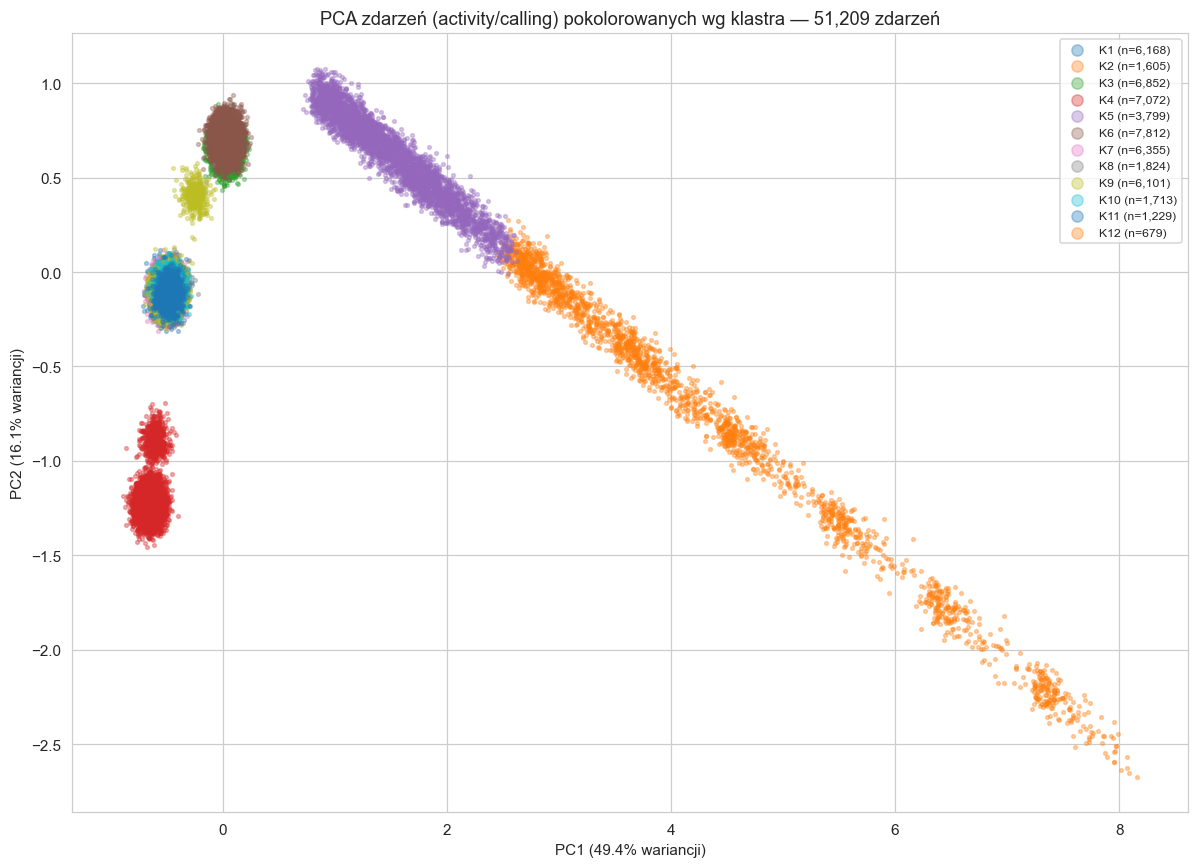

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X)
XY = pca.transform(X)
jit = np.random.normal(0, 0.06, XY.shape)  # jitter — cechy są dyskretne
fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette('tab10', best_k)
for ki in range(best_k):
    m = call['K'].values == ki
    ax.scatter(XY[m,0]+jit[m,0], XY[m,1]+jit[m,1], s=6, alpha=0.35,
               color=palette[ki], label=f'K{ki+1} (n={m.sum():,})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% wariancji)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% wariancji)')
ax.set_title(f'PCA zdarzeń (activity/calling) pokolorowanych wg klastra — {len(call):,} zdarzeń')
ax.legend(markerscale=3, fontsize=8, loc='best')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig_pca_events.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Charakterystyka i nazwanie klastrów
Dla każdego klastra: najczęstsza sygnatura argumentów, statystyki pozycji i dominująca czynność (ta ostatnia tylko opisowo).

In [ ]:
rows = []
for ki in range(best_k):
    sub = call[call['K'] == ki]
    sig = sub['vars_list'].apply(lambda l: ','.join(l) if l else '∅').mode()
    sig = sig.iloc[0] if len(sig) else '∅'
    rows.append({
        'K': f'K{ki+1}', 'n': len(sub),
        'sygnatura_argumentów': sig,
        'position_mediana': (f"{sub.position.median():.0f}" if sub.position.notna().any() else '—'),
        'dominująca_czynność(GT)': sub.activity.value_counts().index[0],
        'czystość': f"{sub.activity.value_counts(normalize=True).iloc[0]*100:.0f}%",
    })
profile = pd.DataFrame(rows)
display(profile)
name_map = {f'K{ki+1}': (rows[ki]['sygnatura_argumentów'] if rows[ki]['sygnatura_argumentów']!='∅'
                          else 'kontrola (bez payloadu)') for ki in range(best_k)}
print('\nNazwy klastrów:')
for k,v in name_map.items(): print(f'  {k}: {v}')

,K,n,sygnatura_argumentów,position_mediana,dominująca_czynność(GT),czystość
0,K1,6168,duration,—,timeout,100%
1,K2,1605,"pid,plateid,position,sampleid",35,Receive sample state,100%
2,K3,6852,"pid,plateid",—,Wait for sample,92%
3,K4,7072,"delete,id,ttl",—,Wait for plate validation,87%
4,K5,3799,"pid,plateid,position,sampleid",9,Receive sample state,100%
5,K6,7812,"pid,sampleid",—,Match patient data,79%
6,K7,6355,attributes,—,Spawn per sample flow,97%
7,K8,1824,∅,—,Sleep,94%
8,K9,6101,stop,—,Callback timeout,95%
9,K10,1713,"createdids,finishids",—,Check for unfinished Plates,100%



Nazwy klastrów:
  K1: duration
  K2: pid,plateid,position,sampleid
  K3: pid,plateid
  K4: delete,id,ttl
  K5: pid,plateid,position,sampleid
  K6: pid,sampleid
  K7: attributes
  K8: kontrola (bez payloadu)
  K9: stop
  K10: createdids,finishids
  K11: level,message
  K12: pid,plateid,position,sampleid


## 5. Porównanie 1:1 z ground truth (`activity`)
Czy klastry odkryte z **samego payloadu** odtwarzają realne kroki procesu? Macierz pomyłek + metryki purity / ARI / NMI.

Purity = 0.927  |  ARI = 0.869  |  NMI = 0.917


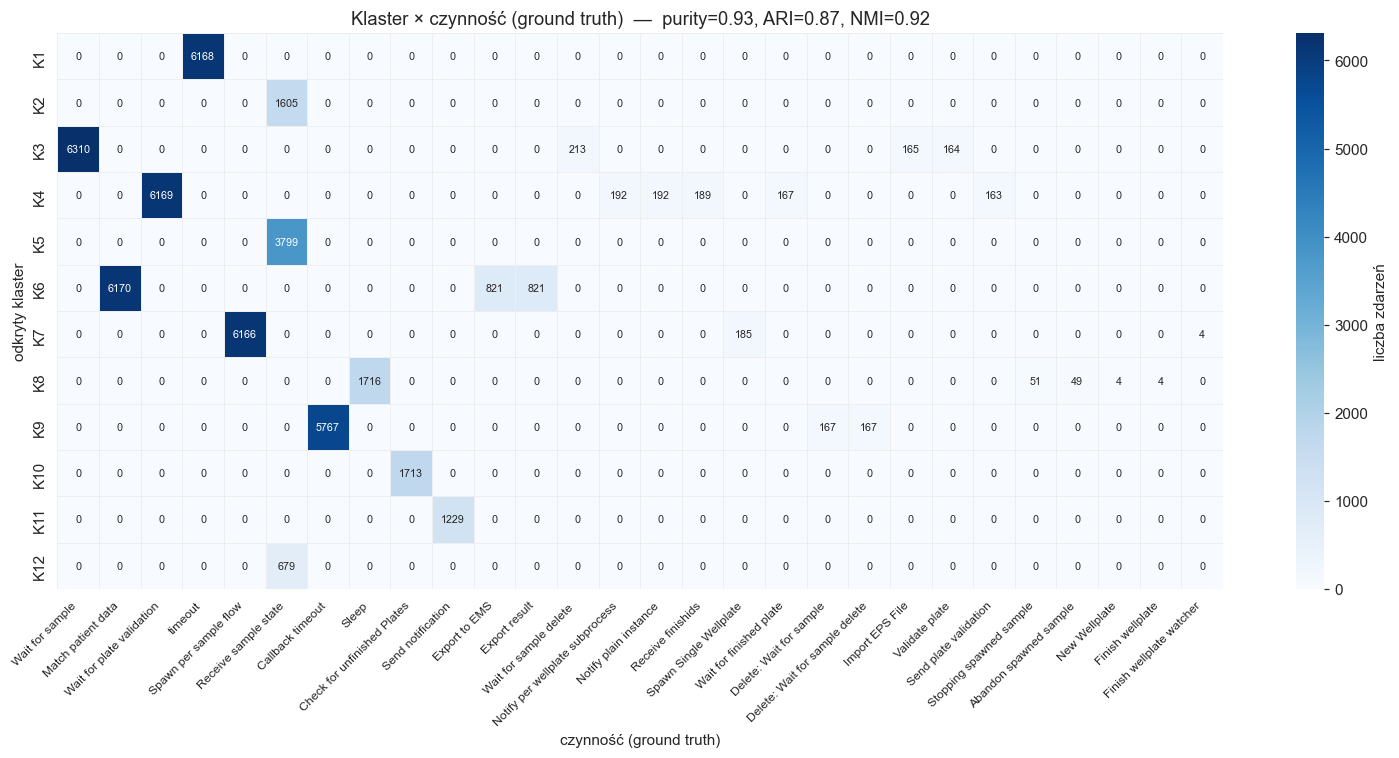

In [ ]:
gt = call['activity'].astype('category')
ari = adjusted_rand_score(gt.cat.codes, call['K'])
nmi = normalized_mutual_info_score(gt.cat.codes, call['K'])
cm = pd.crosstab(call['Klabel'], call['activity'])
purity = cm.max(axis=1).sum() / cm.values.sum()
print(f'Purity = {purity:.3f}  |  ARI = {ari:.3f}  |  NMI = {nmi:.3f}')

# wiersze w naturalnej kolejności K1..Kn, kolumny wg liczności (najczęstsze z lewej)
row_order = sorted(cm.index, key=lambda x: int(x[1:]))
cm_show = cm.loc[row_order, cm.sum().sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(cm_show, annot=True, fmt='d', cmap='Blues', linewidths=0.4, linecolor='#eee',
            cbar_kws={'label':'liczba zdarzeń'}, annot_kws={'size':7}, ax=ax)
ax.set_title(f'Klaster × czynność (ground truth)  —  purity={purity:.2f}, ARI={ari:.2f}, NMI={nmi:.2f}')
ax.set_xlabel('czynność (ground truth)'); ax.set_ylabel('odkryty klaster')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig_cluster_vs_activity.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Sekwencje klastrów w czasie i graf przejść
Dla każdego przypadku: zdarzenia uporządkowane po czasie → sekwencja klastrów (czas służy **tylko** do uporządkowania). Z przejść budujemy graf K_i→K_j.

In [ ]:
call_sorted = call.sort_values(['instance_uuid','timestamp'])
seqs = call_sorted.groupby('instance_uuid')['Klabel'].apply(list)

from collections import Counter
trans = Counter()
for s in seqs:
    for a, b in zip(s, s[1:]):
        trans[(a, b)] += 1

top_variants = Counter(tuple(s) for s in seqs).most_common(8)
print('Najczęstsze warianty sekwencji klastrów:')
for seq, c in top_variants:
    print(f'  {c:5d}×  ' + ' → '.join(seq))

Najczęstsze warianty sekwencji klastrów:
   1124×  K1 → K6 → K4 → K5 → K9
    907×  K1 → K4 → K6 → K5 → K9
    465×  K1 → K6 → K4 → K2 → K9
    351×  K1 → K4 → K6 → K2 → K9
    278×  K6 → K1 → K4 → K5 → K9
    186×  K1 → K6 → K4 → K12 → K9
    161×  K1 → K4 → K6 → K12 → K9
    155×  K6 → K4 → K1 → K5 → K9


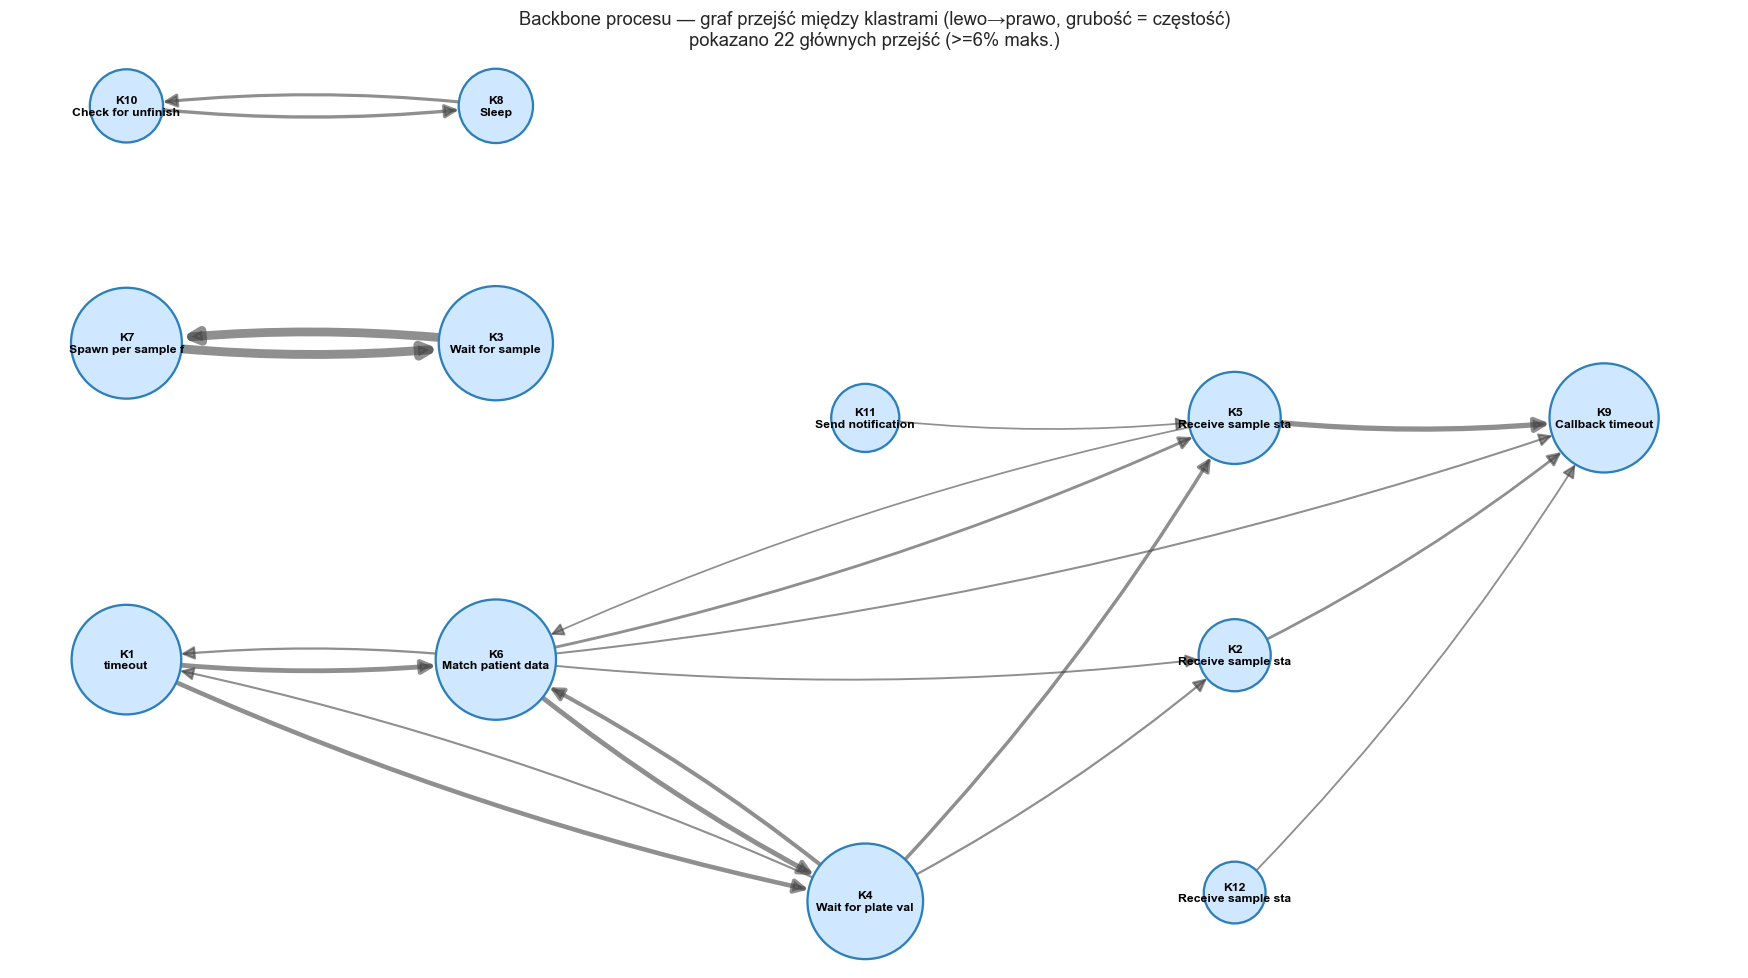

In [ ]:
wmax = max(trans.values())
main_edges = [(a, b, w) for (a, b), w in trans.items() if w >= wmax * 0.06]

G = nx.DiGraph()
G.graph['graph'] = {'rankdir': 'LR'}
for a, b, w in main_edges:
    G.add_edge(a, b, weight=w)

act_short = {f'K{ki+1}': profile.loc[ki, 'dominująca_czynność(GT)'][:18] for ki in range(best_k)}
labels = {n: f"{n}\n{act_short.get(n,'')}" for n in G.nodes()}
pos_g = nx.nx_pydot.graphviz_layout(G, prog='dot')

fig, ax = plt.subplots(figsize=(16, 9))
vc = call['Klabel'].value_counts()
node_sz = [vc.get(n, 1) for n in G.nodes()]
mx = max(node_sz)
node_sz = [1200 + 5000*(s/mx) for s in node_sz]
nx.draw_networkx_nodes(G, pos_g, node_size=node_sz, node_color='#cfe8ff',
                       edgecolors='#2c7fb8', linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos_g, labels=labels, font_size=8, font_weight='bold', ax=ax)
for a, b, w in main_edges:
    if not G.has_edge(a, b):
        continue
    nx.draw_networkx_edges(G, pos_g, edgelist=[(a, b)], width=0.8+5*(w/wmax),
                           alpha=0.6, edge_color='#444', arrowsize=18,
                           node_size=node_sz, connectionstyle='arc3,rad=0.06', ax=ax)
ax.set_title('Backbone procesu — graf przejść między klastrami (lewo→prawo, grubość = częstość)\n'
             f'pokazano {len(main_edges)} głównych przejść (>=6% maks.)')
ax.axis('off')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig_cluster_transitions.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Outliery z perspektywy odkrytego procesu
Outlier = przypadek, którego sekwencja klastrów zawiera **rzadkie przejścia** (spoza głównego grafu). Wyjaśniamy anomalie odkrytym procesem, nie samym czasem trwania.

In [ ]:
total_trans = sum(trans.values())
trans_prob = {k: v/total_trans for k, v in trans.items()}
RARE = sorted(trans_prob.items(), key=lambda kv: kv[1])[:max(1, len(trans_prob)//5)]
rare_set = {k for k, _ in RARE}

def rare_score(seq):
    pairs = list(zip(seq, seq[1:]))
    return sum(1 for p in pairs if p in rare_set)

case_scores = seqs.apply(rare_score)
outliers = case_scores[case_scores > 0].sort_values(ascending=False)
print(f'Przypadków z rzadkimi przejściami klastrów: {len(outliers):,} '
      f'({len(outliers)/len(seqs)*100:.1f}%)')
print('\nNajrzadsze przejścia klastrów (potencjalne anomalie procesu):')
for (a, b), p in RARE[:10]:
    print(f'  {a} → {b}: {p*100:.3f}% przejść')

# zestawienie z czasem trwania (tylko jako odniesienie, NIE jako kryterium)
cases = pd.read_parquet(PROCESSED_DIR / 'pcr_cases.parquet')[['instance_uuid','duration_min']]
od = cases.set_index('instance_uuid').reindex(outliers.index)['duration_min']
print(f"\nMediana duration_min: outliery procesowe={od.median():.0f} "
      f"vs wszystkie={cases.duration_min.median():.0f} (odniesienie)")

Przypadków z rzadkimi przejściami klastrów: 57 (0.9%)

Najrzadsze przejścia klastrów (potencjalne anomalie procesu):
  K7 → K7: 0.002% przejść
  K9 → K4: 0.002% przejść
  K4 → K9: 0.002% przejść
  K11 → K4: 0.002% przejść
  K4 → K8: 0.004% przejść
  K9 → K8: 0.004% przejść
  K7 → K8: 0.009% przejść
  K11 → K12: 0.027% przejść
  K9 → K7: 0.027% przejść
  K11 → K6: 0.027% przejść

Mediana duration_min: outliery procesowe=408 vs wszystkie=175 (odniesienie)


## 8. Podsumowanie
- Klasteryzowaliśmy — surowy payload wywołań CPEE (argumenty czynności) + pozycję na płytce.
- Odkryte klastry **K1..Kn** odpowiadają realnym krokom procesu (patrz purity/ARI/NMI oraz macierz pomyłek), mimo że etykiety `activity` **nie** było wśród cech.